## **ДИСКУРС-АНАЛИЗ СОЛИДАРНОСТИ В ИТОГОВЫХ ДЕКАРАЦИЯХ БРИКС**

Солидарность стран мы будем рассматривать на уровне спич-актов и дискурса, то есть как способ языкового конструирования общности, совместных интересов и коллективного действия 

На уровне текста солидарность может проявляться абсолютно различными способами (как пишет об этом А. Вендт):

- через формирование коллективного субъекта «мы» и общую позицию
- через лексику, означающую поддержку, сотрудничество и совместные обязательства
- через упоминание стран и групп, интересы которых БРИКС стремится защищать (developing countries, Africa, LDCs, Global South), что увидим с помощью графа
- через требования более справедливого и инклюзивного мирового порядка
- через расширение круга тем, в рамках которых артикулируется общность интересов.

Поэтому далее частотный анализ, индекс солидарности, показатели разнообразия акторов и сюжетов, а также сетевой анализ акторов используются как количественные индикаторы того, как именно солидарность оформляется

## Загружаем библиотеки
`pandas` — структура корпуса; `pathlib` — пути; `spaCy` — лемматизация английского; `scikit-learn` — `CountVectorizer` / `TfidfVectorizer`; `networkx` — граф акторов; `scipy` — статистика; `matplotlib` / `seaborn` — визуализация

In [1]:
import os
import re
import json
import math
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
import numpy as np
import pandas as pd

import nltk
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from scipy import stats

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
##warnings.filterwarnings('ignore')
##sns.set_theme(style='whitegrid', context='talk')
##plt.rcParams['figure.figsize'] = (12, 6)
##pd.set_option('display.max_colwidth', 250)

##OUTPUT_DIR = 'output'
##os.makedirs(OUTPUT_DIR, exist_ok=True)

## Загрузка корпуса

Корпус — Excel-файл [`BRICS_declarations_2009-2025.xlsx`](BRICS_declarations_2009-2025.xlsx) рядом с ноутбуком: одна строка = одна итоговая декларация (`year`, `title`, `text`, `url`).

In [3]:
DATA_DIR = Path.cwd()
EXCEL_PATH = DATA_DIR / 'BRICS_declarations_2009-2025.xlsx'

if not EXCEL_PATH.exists():
    raise FileNotFoundError(f'Нет файла Excel: {EXCEL_PATH.resolve()}. Положите его рядом с ноутбуком.')

df = pd.read_excel(EXCEL_PATH)
print('Размер исходного корпуса', df.shape)
display(df.head(10))

Размер исходного корпуса (17, 4)


,year,title,text,url
0,2009,I Summit BRIC Joint Statement of the BRIC Coun...,"We, the leaders of the Federative Republic of ...",https://infobrics.org/en/document/3/
1,2010,II BRIC SUMMIT - JOINT STATEMENT OF THE BRIC C...,"We, the leaders of the Federative Republic of ...",https://infobrics.org/en/document/5/
2,2011,"III BRIC SUMMIT - SANYA DECLARATION APRIL 14, ...","1. We, the Heads of State and Government of th...",https://infobrics.org/en/document/8/
3,2012,"IV BRICS SUMMIT - DELHI DECLARATION MARCH 29, ...","1. We, the leaders of the Federative Republic ...",https://infobrics.org/en/document/12/
4,2013,Fifth BRICS Summit \nDurban: 27 March 2013 \n...,"1. \n2. \nWe, the leaders of the Federative Re...",https://infobrics.org/en/document/15/
5,2014,Sixth BRICS Summit Fortaleza Declaration,"1. We, the leaders of the Federative Republic...",https://infobrics.org/en/document/20/
6,2015,VII BRICS Summit Ufa Declaration,"1. We, the leaders of the Federative Republic ...",https://infobrics.org/en/document/24/
7,2016,"VIII BRICS Summit Goa Declaration Goa, India, ...","1. We, the Leaders of the Federative Republic ...",https://infobrics.org/en/document/87/
8,2017,"BRICS Leaders Xiamen Declaration Xiamen, China...","1. We, the Leaders of the Federative Republic ...",https://infobrics.org/en/document/89/
9,2018,10TH BRICS SUMMIT \nJOHANNESBURG DECLARATION,"PREAMBLE We, the Heads of State and Government...",https://infobrics.org/en/document/91/


## Приводим к единой структуре корпус к формату: одна строка-один документ

In [4]:
required_cols = ['title', 'text', 'year']
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f'Отсутствуют обязательные колонки: {missing}'

In [5]:
# Приведение к канонической схеме
col_map = {
    'title': 'title',
    'text': 'text',
    'year': 'year',
    'url': 'url'
}

for old, new in col_map.items():
    if old in df.columns and new not in df.columns:
        df.rename(columns={old: new}, inplace=True)

In [6]:
# Для этого файла организация одна — BRICS; язык текста по факту английский
if 'org' not in df.columns:
    df['org'] = 'BRICS'
if 'language' not in df.columns:
    df['language'] = 'en'

required_cols = ['title', 'text', 'year']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Отсутствуют обязательные колонки: {missing}')

## Очистка корпуса - убираем шумы, включая лишние пробелы, пустые места --> делаем датафрейм пригодный для анализа текстов

In [7]:
MIN_TEXT_LEN = 200

def basic_clean(text: str) -> str:
    text = str(text)
    text = text.replace("\xa0", " ")
    text = text.replace("\u2009", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalize_year(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"(19|20)\d{2}", str(x))
    return int(m.group()) if m else np.nan


df["text_clean"] = df["text"].apply(basic_clean)
df["year"] = df["year"].apply(normalize_year).astype("Int64")

before = len(df)
df = df[df["text_clean"].str.len() > MIN_TEXT_LEN].copy()
after_len = len(df)


def text_fingerprint(text):
    return re.sub(r"\W+", "", text.lower())[:10000]


df["text_fp"] = df["text_clean"].apply(text_fingerprint)
df = df.drop_duplicates(subset=["text_fp"]).copy()

after = len(df)
print(f"Удалено на этапе очистки: {before - after} (в т.ч. короче {MIN_TEXT_LEN} симв.: {before - after_len})")
print("Итоговый размер корпуса:", df.shape)
display(df[["year", "title", "text"]].head())


Удалено на этапе очистки: 0 (в т.ч. короче 200 симв.: 0)
Итоговый размер корпуса: (17, 8)


,year,title,text
0,2009,I Summit BRIC Joint Statement of the BRIC Coun...,"We, the leaders of the Federative Republic of ..."
1,2010,II BRIC SUMMIT - JOINT STATEMENT OF THE BRIC C...,"We, the leaders of the Federative Republic of ..."
2,2011,"III BRIC SUMMIT - SANYA DECLARATION APRIL 14, ...","1. We, the Heads of State and Government of th..."
3,2012,"IV BRICS SUMMIT - DELHI DECLARATION MARCH 29, ...","1. We, the leaders of the Federative Republic ..."
4,2013,Fifth BRICS Summit \nDurban: 27 March 2013 \n...,"1. \n2. \nWe, the leaders of the Federative Re..."


## Нормализация текста для подсчета устойчивых единиц текста, а не отдельных слов

Например, `cooperation`, `cooperate`, `cooperative` должны соотноситься друг с другом, а не распадаться на разные формы.

In [8]:
import re
import nltk
import spacy


try:
    nlp_en = spacy.load("en_core_web_sm", disable=["ner"])
except Exception as e:
    warnings.warn(f"Модель en_core_web_sm недоступна ({e!r}); используется упрощённая токенизация.")
    nlp_en = spacy.blank("en")

try:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    stop_en = set(stopwords.words("english"))
except Exception:
    stop_en = set()

def lemmatize_en(text: str):
    if len(nlp_en.pipe_names) > 0:
        doc = nlp_en(text)
        return [
            tok.lemma_.lower()
            for tok in doc
            if not tok.is_punct
            and not tok.is_space
            and tok.lemma_.strip()
            and tok.lemma_.lower() not in stop_en
        ]
    else:
        text = text.lower()
        text = re.sub(r"[^a-z\s]", " ", text)
        return [t for t in text.split() if len(t) > 2 and t not in stop_en]

df["lemmas"] = df["text_clean"].apply(lemmatize_en)
df["lemma_text"] = df["lemmas"].apply(lambda xs: " ".join(xs))
df["token_count"] = df["lemmas"].apply(len)

display(df[["year", "token_count", "lemma_text"]].head(3))


C:\Users\vikus\AppData\Local\Temp\ipykernel_24540\4039991789.py:9: UserWarning: Модель en_core_web_sm недоступна (OSError("[E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.")); используется упрощённая токенизация.
  warnings.warn(f"Модель en_core_web_sm недоступна ({e!r}); используется упрощённая токенизация.")


,year,token_count,lemma_text
0,2009,550,leaders federative republic brazil russian fed...
1,2010,1348,leaders federative republic brazil russian fed...
2,2011,1284,heads state government federative republic bra...


##  Прежде чем считать индексы солидарности, полезно просто посмотреть, о чем вообще чаще всего говорится в корпусе
1) Какие слова и формулы доминируют. (Посчитать частоты отдельных слов (лемм) во всех документах, выявить, какие термины встречаются чаще всего.
Смотрим не только на технически частые слова (state, international), но и на политически важные: cooperation, development, multilateral, justice, reform и т.п.
2) какие n-граммы повторяются (устойчивых сочетаниях из 2–3 слов). Например: mutual benefit, shared prosperity, sustainable development, peace and security, inclusive growth., какие выражения особенно характерны для BRICS-документов - через что проявляется солидарность

Это важно методологически, потому что солидарность обычно выражается не одним словом, а словосочетаниями или выражениями

In [10]:
# Папка для сохранения результатов
analysis_BRICS = 'BRICS_discourse'
os.makedirs(analysis_BRICS, exist_ok=True)

# Частоты отдельного слова
vectorizer_uni = CountVectorizer(min_df=2)
X_uni = vectorizer_uni.fit_transform(df['lemma_text'])
terms_uni = np.array(vectorizer_uni.get_feature_names_out())
freq_uni = np.asarray(X_uni.sum(axis=0)).ravel()

freq_term_df = (
    pd.DataFrame({'term': terms_uni, 'freq': freq_uni})
      .sort_values('freq', ascending=False)
      .reset_index(drop=True)
)
display(freq_term_df)

# Частоты выражений
vectorizer_ng = CountVectorizer(ngram_range=(2, 3), min_df=2)
X_ng = vectorizer_ng.fit_transform(df['lemma_text'])
terms_ng = np.array(vectorizer_ng.get_feature_names_out())
freq_ng = np.asarray(X_ng.sum(axis=0)).ravel()

freq_exp_df = (
    pd.DataFrame({'exp': terms_ng, 'freq': freq_ng})
      .sort_values('freq', ascending=False)
      .reset_index(drop=True)
)
display(freq_exp_df)

# Экспорт описательных таблиц
freq_term_df.to_csv(
    os.path.join(analysis_BRICS, 'brics_word_frequencies.csv'),
    index=False
)
freq_exp_df.to_csv(
    os.path.join(analysis_BRICS, 'brics_expressions_frequencies.csv'),
    index=False
)

,term,freq
0,brics,707
1,international,609
2,cooperation,533
3,development,530
4,countries,420
...,...,...
2518,revenue,2
2519,wmd,2
2520,withdrawal,2
2521,winter,2


,exp,freq
0,united nations,164
1,sustainable development,134
2,brics countries,118
3,developing countries,117
4,international law,90
...,...,...
9886,wto imf international,2
9887,abuses acts,2
9888,abuses acts violence,2
9889,accelerate delivery humanitarian,2


## Мы получили доминирующие слова в корпусе.
1) На уровне отдельных лемм корпус характеризуется высокой частотой лексики 1) кооперации и обязательств (**cooperation, support, commitment, efforts, reaffirm**),2) развития (**development, economic, growth, developing**), 3) многостороннего глобального управления (**international, global, multilateral, trade, security, peace**)
2) На уровне n‑грамм устойчиво повторяются формулы, которые оформляют солидарность через поддержку ООН и международного права (**united nations, international law, international community, multilateral trading system**), через повестку устойчивого развития и защиты развивающихся стран (**sustainable development, developing countries, economic growth, climate change**), а также через внутреннюю кооперацию стран БРИКС (**brics cooperation, brics countries, among brics, working group**) и речевые акты подтверждения общих обязательств (**reaffirm commitment, reiterate commitment, call upon**)

## Теперь мы можем сформулировать 4 измерения солидарности для выявления форм солидарности
Почему именно эти 4 измерения? На уровне лексики и n‑грамм видно, что солидарность BRICS проявляется по крайней мере в четырёх различных, но взаимосвязанных формах.

1) Нормативная солидарность
В корпусе многократно появляются устойчивые формулы, отсылающие к международному праву и универсальным нормам: **united nations, international law, peace security, human rights, general assembly**
-->  солидарность «через нормы» - апелляция к справедливому, инклюзивному и правозаконному мировому порядку, основанному на общих принципах и правах

2) Кооперативная / институциональная солидарность
Высокая частота лексики кооперации и обязательств (**cooperation, support, commitment, efforts, reaffirm, reiterate, call, look forward**), а также выражений типа **brics cooperation, among brics, working group, meeting brics, cooperation among** указывает на то, что значимая часть солидарности артикулируется через совместные действия, механизмы и институционализированные форматы взаимодействия
--> солидарность - это, прежде всего, готовность действовать вместе и координировать позиции

3) Реформаторская солидарность
Устойчивые выражения, связанные с ООН и многосторонней торговой системой (**security council, multilateral trading system, international cooperation, international community**), в сочетании с лексикой угроз и асимметрий (**terrorism, counter terrorism, sanctions, unilateral measures, reform of global governance** — по расширенному списку лексикона)
--> солидарность как совместное противостояние иерархичному, одностороннему порядку и как требование его реформы + стремление реформировать институтов глобального управления в интересах стран Глобального Юга

4) Солидарность в развитии
Доминирующая связка **development, economic, growth, developing, sustainable development, developing countries, economic growth, trade investment, climate change** показывают, что для BRICS солидарность - это ещё и совместное продвижение повестки устойчивого развития, поддержки развивающихся стран и требований к перераспределению ресурсов (финансирование, инфраструктура, технологии, climate finance)
--> солидарность понимается как совместное развитие 

In [11]:
norms_lex = {
    'solidarity', 'justice', 'equity', 'fairness', 'equality',
    'inclusive', 'inclusiveness',
    'rights', 'human rights', 'dignity',
    'responsibility', 'responsibilities', 'shared', 'common',
    'collective', 'mutual', 'respect',
    'rule of law', 'sovereign equality',
    'common but differentiated responsibilities',
    'multipolar', 'multilateralism',
    'inclusive growth', 'shared prosperity', 'shared responsibility'
}

cooperation_lex = {
    'cooperation', 'cooperate', 'cooperative', 'coordination', 'coordinate', 'joint',
    'partnership', 'partnerships', 'mechanism', 'mechanisms', 'framework', 'working group',
    'task force', 'common position', 'common stand', 'collective action', 'pool resources',
    'institutional collaboration', 'consensus', 'exchange', 'capacity building', 'brics cooperation', 
    'cooperation among', 'joint statement'
}

reform_lex = {
    'unilateral', 'unilateral measures',
    'sanctions', 'coercive', 'coercion',
    'hegemonic', 'hegemony',
    'domination', 'dominance',
    'neo colonial', 'neocolonial',
    'reform', 'reforms', 'reforming',
    'global governance',
    'security council reform',
    'multilateral trading system',
    'underrepresentation',
    'non interference'
}
development_lex = {
    'development', 'sustainable development',
    'infrastructure', 'finance', 'financing',
    'development bank', 'new development bank',
    'investment', 'economic growth',
    'technology transfer', 'capacity building',
    'industrialisation', 'industrialization',
    'poverty', 'food security',
    'health', 'education',
    'climate finance',
    'digital', 'connectivity',
    'sdgs', 'developing countries', 'social development'
}

lexs = {
    'norm': norms_lex,
    'cooperation': cooperation_lex,
    'reform': reform_lex,
    'development': development_lex,
}

## Количественный анализ, т.е. отвечаем на вопрос: насколько интенсивно и в каких формах солидарность артикулируется в официальном дискурсе

Словари для 4 измерений солидарности --> необходимо превратить их в показатели, которые можно посчитать для каждого документа и затем сравнивать между собой. Иначе говоря, мы переводим качественные данные («здесь много кооперации», «здесь сильнее критика мирового порядка») в количественные индексы.

Для каждого текста мы считаем:
- сколько раз в нем встречаются слова и устойчивые выражения из соответствующего словаря (например, кооперативного)
- полученное число делим на общую длину документа, чтобы длинные и короткие тексты можно было сопоставлять на одной шкале (правило равномерности)
- стандартную нормировку по всему корпусу (z), чтобы видеть, какие документы выражают то или иное измерение солидарности заметно сильнее или слабее средних значений

In [12]:
# На всякий случай: убираем старые колонки индексов, если они уже были в df
for suffix in ['_raw', '_freq', '_freq_z']:
    cols_to_drop = [c for c in df.columns if c.endswith(suffix) and any(
        c.startswith(prefix) for prefix in ['norm', 'cooperation', 'reform', 'development']
    )]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [13]:
def count_lexicon_items(lemmas, lexicon):
    
    text_joined = ' '.join(lemmas)
    count = 0
    for item in lexicon:
        if ' ' in item:  # многословное выражение
            count += text_joined.count(item)
        else:            # одиночная лемма
            count += lemmas.count(item)
    return count


def compute_lexicon_indices_row(row):
    lemmas = row['lemmas']
    total_tokens = len(lemmas) if len(lemmas) > 0 else 1

    counts = {}
    freqs = {}

    for dim, lex in lexs.items():
        raw = count_lexicon_items(lemmas, lex)
        counts[f'{dim}_raw'] = raw
        freqs[f'{dim}_freq'] = raw / total_tokens

    return pd.Series({**counts, **freqs, 'tokens': total_tokens})


#  Применяем к корпусу (один раз)

lex_df = df.apply(compute_lexicon_indices_row, axis=1)
df = pd.concat([df, lex_df], axis=1)

#  Z-нормировка и интегральный индекс солидарности

for col in ['norm_freq', 'cooperation_freq', 'reform_freq', 'development_freq']:
    mean = float(df[col].mean())
    std = float(df[col].std(ddof=0))
    if std == 0 or np.isnan(std):
        std = 1.0
    df[col + '_z'] = (df[col] - mean) / std

weights = {
    'norm_freq_z': 0.25,
    'cooperation_freq_z': 0.25,
    'reform_freq_z': 0.25,
    'development_freq_z': 0.25,
}

df['solidarity_index'] = sum(df[col] * w for col, w in weights.items())

#Быстрый просмотр результата

display(df[['year',
            'norm_freq', 'cooperation_freq', 'reform_freq', 'development_freq',
            'solidarity_index']])

,year,norm_freq,cooperation_freq,reform_freq,development_freq,solidarity_index
0,2009,0.018182,0.029091,0.005455,0.032727,0.055469
1,2010,0.017062,0.022997,0.006677,0.031157,-0.071602
2,2011,0.014798,0.036604,0.003894,0.037383,0.019224
3,2012,0.009109,0.025347,0.003960,0.039208,-0.527372
4,2013,0.011254,0.019293,0.004421,0.059887,-0.025398
5,2014,0.019692,0.020766,0.005013,0.028643,-0.228759
6,2015,0.022752,0.036971,0.004977,0.028795,0.359307
7,2016,0.022825,0.022468,0.004636,0.032810,0.042380
8,2017,0.016913,0.052502,0.003171,0.046512,0.692133
9,2018,0.023654,0.022198,0.005095,0.022562,-0.118757


## Теперь у нас есть средняя интенсивность разных форм солидарности в документах БРИКС + единый индекс

**solidarity_index** - сводный показатель: если он выше 0, то в данном году в среднем солидарность выражена сильнее, чем по корпусу в целом, если ниже 0 - слабее. (ФОРМУЛА: z = (X - μ)/σ) 

Например:
2009 - все четыре измерения на определённом уровне, интегральный индекс чуть выше среднего → в этот год лексика в среднем более «солидарна» по сравнению с общим фоном
2012 - частоты измерений немногим отличаются, но индекс отрицательный → по отношению к среднему по корпусу этот год выглядит менее «насыщенным» солидарностью.

2013: development_freq заметно выше, но в сумме год всё ещё близок к среднему.

## Отдельно про индекс солидарности
- он поззволяет оценить степень выражения в официальных документах лексических конструкций

Еще про результаты: 

1) В ранних декларациях наблюдается использование общих формулировок, характерных для бюрократического и дипломатического языка, присущий декларациям, коммюнике и т.д.
2)  Однако в последующие годы наблюдается тенденция к более четкому и структурированному выражению солидарности, что проявляется в формировании коллективной позиции, направленной на защиту интересов развивающихся государств, а также в выдвижении требований к реформированию глобального управления

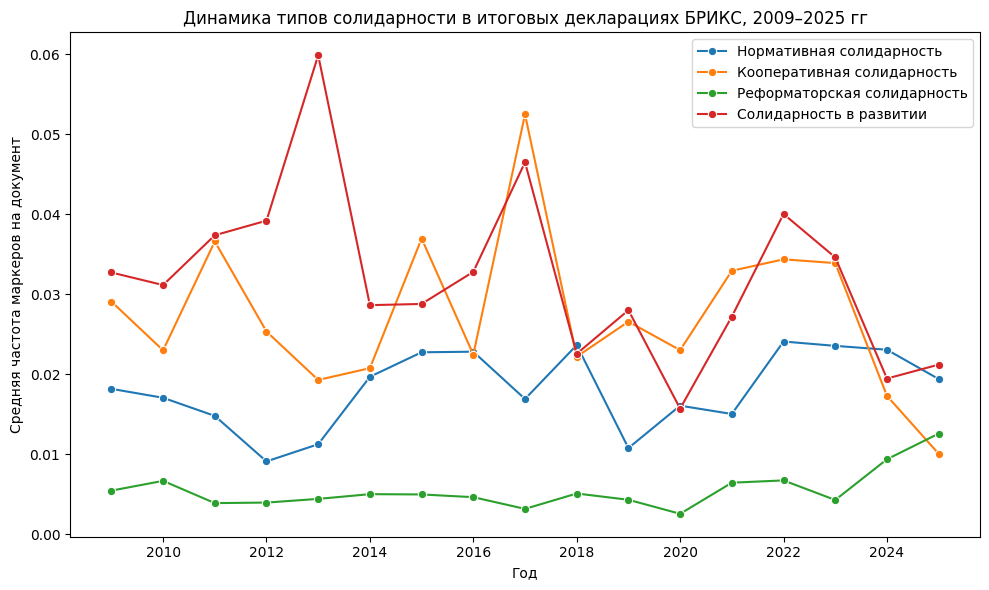

In [17]:
by_year = (
    df.groupby('year')[['norm_freq', 'cooperation_freq', 'reform_freq', 'development_freq']]
      .mean()
      .reset_index()
      .sort_values('year')
)

plt.figure(figsize=(10, 6))
for col, label in [
    ('norm_freq', 'Нормативная солидарность'),
    ('cooperation_freq', 'Кооперативная солидарность'),
    ('reform_freq', 'Реформаторская солидарность'),
    ('development_freq', 'Солидарность в развитии ')
]:
    sns.lineplot(data=by_year, x='year', y=col, marker='o', label=label)

plt.title('Динамика типов солидарности в итоговых декларациях БРИКС, 2009–2025 гг')
plt.xlabel('Год')
plt.ylabel('Средняя частота маркеров на документ')
plt.legend()
plt.tight_layout()
plt.show()

## Интерпретация
**Синяя** - нормативная солидарность (частота маркеров прав и норм (justice, equality, human rights, rule of law, multilateralism и др)
Линия довольно стабильна и ниже остальных → почти всегда апеллирует к нормам, НО скорее «фон» для других форм солидарности

**Оранжевая** - кооперативная солидарность (маркеры cooperation, partnership, framework, working group, joint statement и др.)
В начале периода кооперативный язык заметно выражен, затем колеблется, с отдельными всплесками (видно подъёмы примерно в районе середины 2010‑х и после 2020 г.) --> ЭТО усиливает акцент на совместных механизмах и институциональном оформлении солидарности

**Зелёная** - реформаторская солидарность (маркеры reform, global governance, multilateral trading system, unilateral measures, sanctions и др.)
Линия остаётся самой низкой: стремление к реформам присутствует постоянно, хотя и менее интенсивен, чем кооперация и развитие

**Красная** — солидарность в развитии (маркеры development, sustainable development, developing countries, economic growth, poverty reduction, climate finance и др.)Почти во все годы эта линия выше других и даёт яркие пики. Это означает, что развитие и устойчивый рост - главный канал, через который БРИКС выражает солидарность: поддержка развивающихся стран, повестка SDGs, инфраструктура, финансирование и т.п. - наиболее устойчив

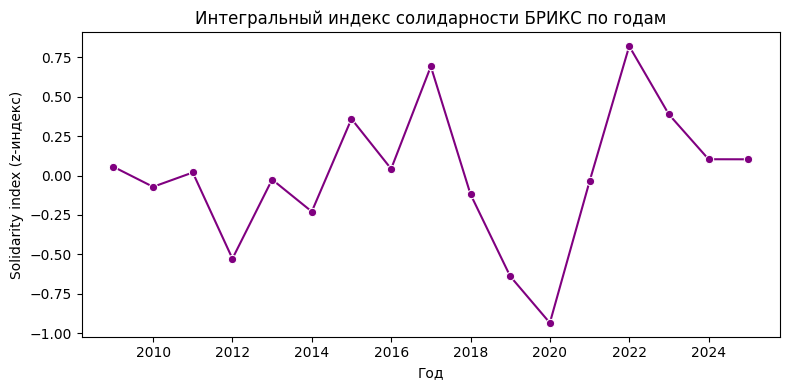

In [18]:
by_year_index = (
    df.groupby('year')['solidarity_index']
      .mean()
      .reset_index()
      .sort_values('year')
)

plt.figure(figsize=(8, 4))
sns.lineplot(data=by_year_index, x='year', y='solidarity_index', marker='o', color='purple')
plt.title('Интегральный индекс солидарности БРИКС по годам')
plt.xlabel('Год')
plt.ylabel('Solidarity index (z-индекс)')
plt.tight_layout()
plt.show()

## Интерпретация

Отрицательные значения индекса в начале 2010‑х годов указывают на сравнительно более низкую насыщенность документального корпуса солидарным языком по сравнению со средними значениями по всему периоду

Начиная с середины десятилетия наблюдаются отчётливые подъёмы, а наибольший пик приходится на начало 2020‑х, когда интегральный индекс существенно превышает нулевую отметку.

--> временные фазы консолидации и выражения более сильной политической солидарности, чередующихся с периодами, когда солидарность звучит в итоговых документах заметно слабее

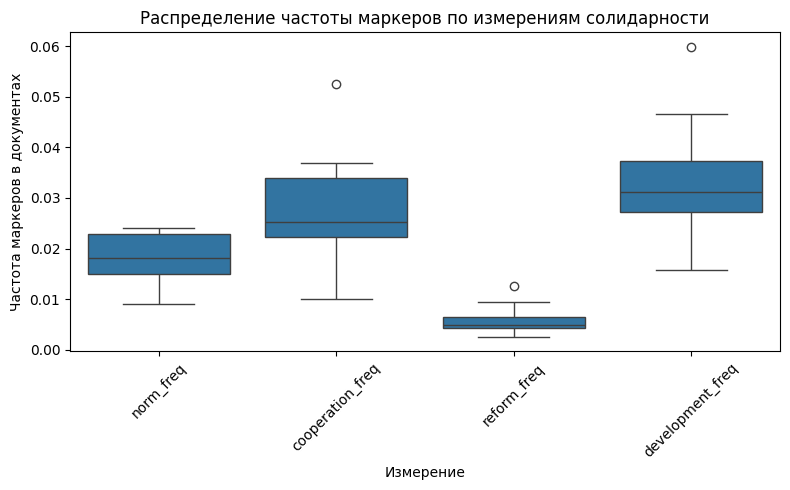

In [19]:
melted = df.melt(
    value_vars=['norm_freq', 'cooperation_freq', 'reform_freq', 'development_freq'],
    var_name='dimension',
    value_name='freq'
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=melted, x='dimension', y='freq')
plt.xticks(rotation=45)
plt.title('Распределение частоты маркеров по измерениям солидарности')
plt.xlabel('Измерение')
plt.ylabel('Частота маркеров в документах')
plt.tight_layout()
plt.show()

## Интерпретация
Наиболее интенсивно выражена солидарность через развитие

Медианные значения частоты маркеров «development_freq» и «cooperation_freq» превосходят аналогичные показатели для «norm_freq» и «reform_freq», причём реформаторская солидарность имеет не только самый низкий уровень, но и наименьший разброс ценностей

--> вне зависимости от конкретного года большинство итоговых документов структурируется прежде всего вокруг развития и сотрудничества

## Контекстный индекс - какие акторы и какие ключевые слова появляются рядом с маркерами солидарности.

Идея заключается в следующем: если в контексте терминов 'cooperation', 'solidarity', 'partnership" и 'joint' регулярно упоминаются различные страны, регионы и политические темы, это свидетельствует о том, что солидарность выражается не абстрактно

In [20]:
# Маркеры солидарности: слова, вокруг которых мы ищем контекст
solidarity_markers = {
    'solidarity', 'cooperation', 'cooperate', 'partnership', 'joint', 'consensus',
    'collective', 'mutual', 'coordination'
}

# Страны, с которыми может быть связана солидарность
solidarity_actors = {
    'brazil', 'russia', 'india', 'china', 'south africa', 'africa',
    'developing countries', 'least developed countries', 'emerging markets',
    'global south', 'brics', 'united nations', 'wto', 'imf', 'world bank'
}

# Темы, в которых проявляется солидарность
solidarity_issue = {
    'trade', 'investment', 'finance', 'debt', 'climate', 'adaptation', 'mitigation',
    'security', 'terrorism', 'health', 'pandemic', 'vaccine', 'education',
    'infrastructure', 'technology', 'development', 'poverty', 'food security',
    'human rights'
}

WINDOW = 5  # размер окна по леммам вокруг маркера солидарности

In [26]:
def context_indices(lemmas, window=WINDOW):
    anchor_positions = [i for i, tok in enumerate(lemmas) if tok in solidarity_markers]
    if not anchor_positions:
        return 0, 0

    partners = set()
    issues = set()

    for pos in anchor_positions:
        left = max(0, pos - window)
        right = min(len(lemmas), pos + window + 1)
        window_tokens = lemmas[left:right]
        window_text = ' '.join(window_tokens)

        for actor in solidarity_actors:
            if actor in window_text:
                partners.add(actor)

        for issue in solidarity_issue:
            if issue in window_text:
                issues.add(issue)

    return len(partners), len(issues)


def compute_context_row(row):
    lemmas = row['lemmas']
    p, i = context_indices(lemmas)
    return pd.Series({
        'partner_diversity': p,
        'issue_diversity': i
    })

# Считаем один раз
context_df = df.apply(compute_context_row, axis=1)
df = pd.concat([df, context_df], axis=1)

In [29]:
#если несколько раз уже прогон был - df = df.loc[:, ~df.columns.duplicated()]

In [31]:
display(df[['year', 'partner_diversity', 'issue_diversity']])

,year,partner_diversity,issue_diversity
0,2009,0,4
1,2010,5,7
2,2011,3,8
3,2012,8,5
4,2013,2,7
5,2014,2,7
6,2015,3,5
7,2016,4,7
8,2017,10,13
9,2018,5,7


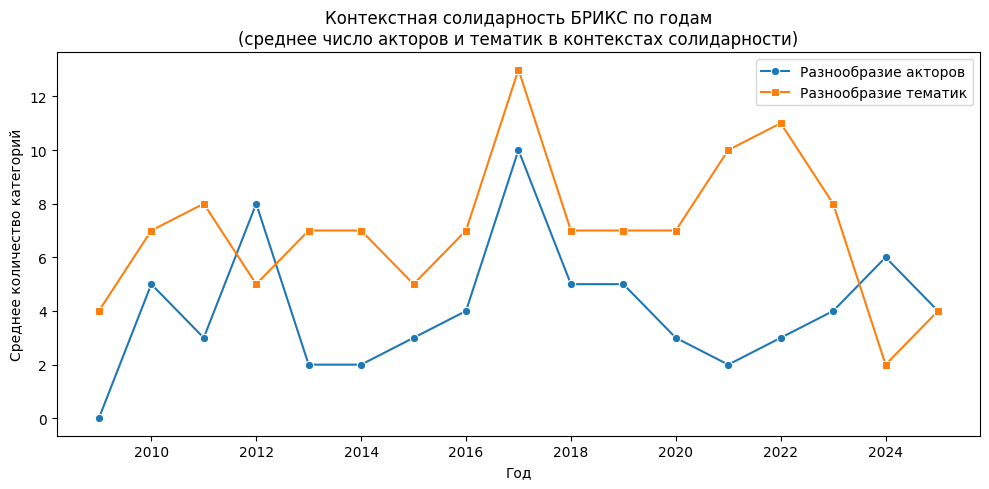

In [35]:
#  Строим график
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=context_by_year,
    x='year',
    y='partner_diversity',
    marker='o',
    label='Разнообразие акторов'
)
sns.lineplot(
    data=context_by_year,
    x='year',
    y='issue_diversity',
    marker='s',
    label='Разнообразие тематик'
)

plt.title('Контекстная солидарность БРИКС по годам\n(среднее число акторов и тематик в контекстах солидарности)')
plt.xlabel('Год')
plt.ylabel('Среднее количество категорий')
plt.legend()
plt.tight_layout()
plt.show()

## Интерпретация

-`partner_diversity` - насколько широк круг акторов, с которыми БРИКС дискурсивно связывает себя в декларациях. Если значение растёт, значит, что солидарность выражается не только внутри самого объединения, но и за пределами.

-`issue_diversity` - насколько разнообразны темы, в рамках которых формулируется эта солидарность. Рост этого показателя = солидарность проявляется не только в риторике экономического развития, но и в ряде других более широких вопросов 


Чем больше таких акторов «подтянуты» к высказываниям солидарности, тем менее это просто абстрактная декларация

1) Синяя линия («Разнообразие акторов») - среднее число разных акторов, которые появляются рядом с маркерами солидарности (solidarity, cooperation, partnership, joint, mutual и др.) в документах каждого года. Сюда входят БРИКС, отдельные страны, «developing countries», «Global South», UN, IMF, World Bank и т.п.
    Оранжевая линия («Разнообразие тематик») - среднее число разных тематических повесток (trade, development, climate, security, terrorism, health, human rights и др.)
--> показывают насыщенность 

2) Результаты


**Начальный период (примерно до середины 2010‑х)**
В начале видно относительно умеренное и волнообразное разнообразие как акторов, так и тематик - вокруг ограниченного круга партнёров (сами страны и ООН) и достаточно типичных тем (торговля, развитие, безопасность), без устойчивого расширения этой сети.

**Пики - 2016-2018**
Резко растёт количество и акторов, и тем, связанных с солидарностью. Это означает, что в эти годы солидарность проговаривается одновременно:
--> БРИКС стремится позиционировать себя узлом более широкого солидарного поля Глобального Юга, а не только клубом пяти стран.

**Фаза тематического расширения 2020-2023**
В более поздние годы оранжевая линия (тематики) идёт выше синей:  расширяет тематическое поле солидарности быстрее, чем акторное: одни и те же партнёры фигурируют в более широком наборе повесток

## Строим граф:
- вершины — акторы (страны, организации, регионы),
- ребро возникает, если они совместно упомянуты в предложении или фрагменте, где присутствует лексика солидарности,
- вес ребра = частота таких совместных упоминаний

In [36]:
# Паттерны акторов (без странного символа \b в начале)
ACTOR_PATTERNS_EN = {
    r'\bbrazil\b': 'Brazil',
    r'\brussia\b': 'Russia',
    r'\bindia\b': 'India',
    r'\bchina\b': 'China',
    r'\bsouth africa\b': 'South Africa',
    r'\bafrica\b': 'Africa',
    r'\bglobal south\b': 'Global South',
    r'\bdeveloping countries\b': 'Developing countries',
    r'\bleast developed countries\b': 'LDCs',
    r'\bunited nations\b': 'UN',
    r'\bwto\b': 'WTO',
    r'\bimf\b': 'IMF',
    r'\bworld bank\b': 'World Bank',
    r'\bbrics\b': 'BRICS'
}

# 2. Маркер солидарности (если уже есть SOLIDARITY_ANCHORS_EN, используй его)
SOLIDARITY_ANCHORS_EN = {
    'solidarity', 'cooperation', 'cooperate', 'partnership', 'joint', 'consensus',
    'collective', 'mutual', 'coordination'
}


def sentence_split(text: str):
    sents = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sents if s.strip()]


def extract_actors_from_text(text: str):
    text_low = text.lower()
    actors = set()
    for pattern, name in ACTOR_PATTERNS_EN.items():
        if re.search(pattern, text_low):
            actors.add(name)
    return actors


def has_solidarity_anchor(text: str):
    t = text.lower()
    return any(anchor in t for anchor in SOLIDARITY_ANCHORS_EN)


def build_solidarity_graph(df_sub):
    G = nx.Graph()

    for _, row in df_sub.iterrows():
        text = row['text_clean']
        if not isinstance(text, str) or not text.strip():
            continue

        sents = sentence_split(text)

        for sent in sents:
            if not has_solidarity_anchor(sent):
                continue

            actors = list(extract_actors_from_text(sent))
            if len(actors) < 2:
                continue

            for a, b in combinations(sorted(actors), 2):
                if G.has_edge(a, b):
                    G[a][b]['weight'] += 1
                else:
                    G.add_edge(a, b, weight=1)

    return G


# Строим граф по всему корпусу 
G = build_solidarity_graph(df)

print('Число узлов:', G.number_of_nodes())
print('Число рёбер:', G.number_of_edges())

# Центральности
if G.number_of_nodes() > 0:
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

    centrality_df = (
        pd.DataFrame({
            'actor': list(degree_centrality.keys()),
            'degree_centrality': list(degree_centrality.values()),
            'betweenness_centrality': [betweenness_centrality[a] for a in degree_centrality.keys()]
        })
        .sort_values('degree_centrality', ascending=False)
        .reset_index(drop=True)
    )
else:
    centrality_df = pd.DataFrame(columns=['actor', 'degree_centrality', 'betweenness_centrality'])

display(centrality_df)

Число узлов: 14
Число рёбер: 35


,actor,degree_centrality,betweenness_centrality
0,BRICS,0.923077,0.551282
1,Africa,0.615385,0.051282
2,Brazil,0.538462,0.000000
3,China,0.461538,0.000000
4,Russia,0.461538,0.435897
5,India,0.461538,0.000000
6,South Africa,0.461538,0.000000
7,Developing countries,0.384615,0.166667
8,LDCs,0.307692,0.051282
9,WTO,0.307692,0.320513


Узлы в визуализированном подграфе: 12
Рёбра (weight ≥ 2 ): 29


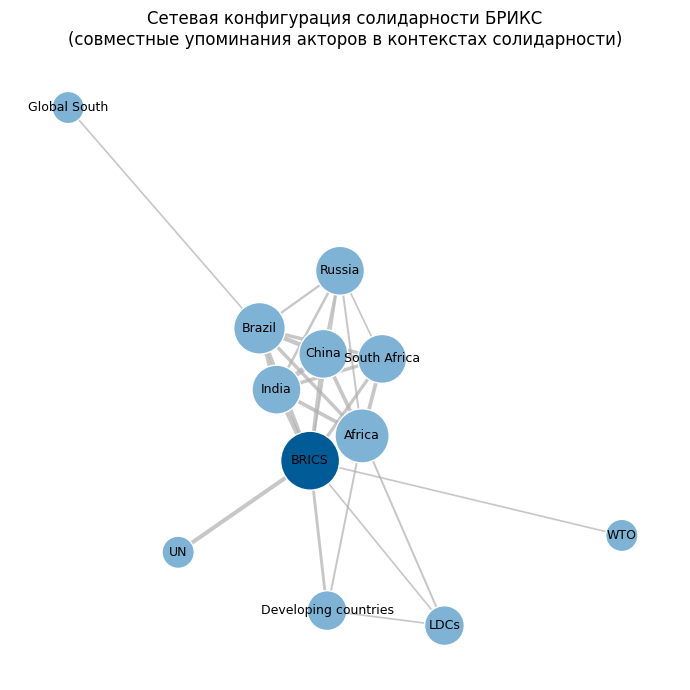

In [37]:
## Визуализация сети солидарности БРИКС

min_weight = 2      # порог по весу ребра
top_labels = 13     # сколько акторов вообще показывать (если узлов много)

# Фильтруем рёбра и берём подграф
edges_to_keep = [(u, v) for u, v, d in G.edges(data=True) if d.get('weight', 1) >= min_weight]
H = G.edge_subgraph(edges_to_keep).copy()

print('Узлы в визуализированном подграфе:', H.number_of_nodes())
print('Рёбра (weight ≥', min_weight, '):', H.number_of_edges())

if H.number_of_nodes() == 0:
    print('Подграф пуст — нет рёбер с весом ≥', min_weight)
else:
    # Берём наиболее центральные узлы (по степени)
    degrees = dict(H.degree())
    if len(degrees) > top_labels:
        keep_nodes = sorted(degrees, key=degrees.get, reverse=True)[:top_labels]
        H = H.subgraph(keep_nodes).copy()
        degrees = dict(H.degree())

 # Ставим BRICS в центр, остальные вокруг
    if 'BRICS' in H.nodes:
        pos_init = nx.spring_layout(H, k=0.8, seed=42, weight='weight')
        # BRICS в центр
        pos_init['BRICS'] = np.array([0.0, 0.0])
        # ещё раз немного «распрямляем» с фиксированным положением BRICS
        pos = nx.spring_layout(H, pos=pos_init, fixed=['BRICS'], k=0.8, seed=42, weight='weight')
    else:
        pos = nx.spring_layout(H, k=0.8, seed=42, weight='weight')

 # Параметры стиля
    weights = [H[u][v]['weight'] for u, v in H.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [0.8 + 3.2 * (w / max_w) for w in weights]

    max_deg = max(degrees.values()) if degrees else 1
    node_sizes = [400 + 1400 * (deg / max_deg) for deg in degrees.values()]

 # Цвета
    node_colors = []
    for n in H.nodes():
        if n == 'BRICS':
            node_colors.append('#005b96')  
        else:
            node_colors.append('#7fb3d5') 

    plt.figure(figsize=(7, 7))

# Рёбра
    nx.draw_networkx_edges(
        H, pos,
        width=edge_widths,
        edge_color='#B0B0B0',
        alpha=0.7
    )

# Узлы
    nx.draw_networkx_nodes(
        H, pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='white',
        linewidths=1.0
    )

 # Подписи
    nx.draw_networkx_labels(
        H, pos,
        font_size=9,
        font_family='DejaVu Sans'
    )

    plt.title('Сетевая конфигурация солидарности БРИКС\n(совместные упоминания акторов в контекстах солидарности)',
              fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Интерпретация 

Сетевой анализ показывает, как в декларациях БРИКС распределяются связи между ключевыми акторами, вокруг которых строится дискурс солидарности 

Из графа видно:
1)  БРИКС как центральный посредник между развивающимися странами и институтами ГУ
2) БРИКС сосредоточен на вопросах не только его членов, но и выходит за пределы площадки
3) Связь с ООН, ВТО говорит о том, что БРИКС выступает как так называемый "коллективный актор", который через язык солидарности внедряет развивающиеся страны в дискуссии об ООН и многосторонней торговой системе, в частности

## Ограничения метода
Мы лишь исследуем, кто, что и как говорит, но не рассматриваем реальные мотивы акторов
Данный корпус данных состоит из 17 англоязычных итоговых деклараций саммитов БРИКС, но ограничивает анализ официальным дискурсом, не включая СМИ, например
Количественная оценка понятия солидарности через частотный анализ терминов, индексы и сетевые параметры неизбежно опирается на выбранные словари, словарные единицы, включая интуитивные методы, что не охватывает все возможные вариации анализа